## Imports + configuration

In [66]:
%pip install tqdm


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [67]:
import os
import glob
import math
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

from scipy.sparse import csr_matrix, eye
from scipy.sparse.linalg import spsolve

In [68]:
# ============================================================
# Configuration
# ============================================================

DATASET_DIR = "dataset"

# ------------------------------------------------------------
# Successor Representation cache
# ------------------------------------------------------------

# IMPORTANT:
# Keep the cache directory name tied to the SR hyperparameters.
# This prevents accidentally loading an old gamma/region cache.
SR_CACHE_DIR = "dataset_sr_gamma099_8x8"

IMAGE_SIZE = 64

BATCH_SIZE = 32
NUM_EPOCHS = 100

LEARNING_RATE = 2e-4

TIMESTEPS = 1000

LATENT_CHANNELS = 16
BASE_CHANNELS = 64

TRAIN_RATIO = 0.9
NUM_WORKERS = 4
PREFETCH_FACTOR = 4
PERSISTENT_WORKERS = True

SEED = 42

# Weighted x0 reconstruction:
# background = 1
# GT path    = PATH_WEIGHT
PATH_WEIGHT = 5.0


# ------------------------------------------------------------
# Test-time SR shuffle experiment
# ------------------------------------------------------------
# IMPORTANT:
# Training is ALWAYS done with the correct matched SR:
#
#     Map A + SR(A) -> Path A
#
# Only after the fresh model has finished training do we run
# a second evaluation with mismatched SR:
#
#     Map A + SR(B) -> prediction
#
# The model weights are identical in both evaluations.
TRAIN_WITH_SHUFFLED_SR = False

# Fixed mapping used only for the shuffled evaluation.
TEST_TIME_SHUFFLE_SEED = 123

# Reset the diffusion sampling RNG before BOTH evaluations.
# This makes the Correct-SR and Shuffled-SR evaluations use
# the same stochastic sampling sequence as far as possible.
EVAL_SEED = 2026

# ------------------------------------------------------------
# SR configuration
# ------------------------------------------------------------

# Long-horizon random-walk representation
SR_GAMMA = 0.99

# 8 x 8 fixed spatial regions
# -> 64 successor-feature channels
SR_REGIONS_PER_AXIS = 8
SR_CHANNELS = SR_REGIONS_PER_AXIS ** 2

# Original map channels:
# obstacle / start / goal
MAP_CHANNELS = 3

# Dataset returns:
# 3 original channels + 64 SR channels = 67
ENCODER_INPUT_CHANNELS = MAP_CHANNELS + SR_CHANNELS

# ------------------------------------------------------------
# Encoder branch widths
# ------------------------------------------------------------

MAP_BRANCH_CHANNELS = 16
SR_BRANCH_CHANNELS = 32

CHECKPOINT_DIR = (
    "checkpoints_cognitive_SR64_test time shuffle_gamma099_"
    "x0+path-weighted"
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)
print("SR gamma:", SR_GAMMA)
print("SR regions:", SR_REGIONS_PER_AXIS, "x", SR_REGIONS_PER_AXIS)
print("SR channels:", SR_CHANNELS)
print("Dataset conditioning channels:", ENCODER_INPUT_CHANNELS)

Device: cuda
SR gamma: 0.99
SR regions: 8 x 8
SR channels: 64
Dataset conditioning channels: 67


In [69]:
# ============================================================
# Reproducibility
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.makedirs(
    CHECKPOINT_DIR,
    exist_ok=True
)

## Successor Representation cognitive map

In [70]:
# ============================================================
# Successor Representation utilities
# ============================================================

def build_random_walk_transition_csr(obstacle_map):
    """
    Build sparse random-walk transition matrix P.

    Parameters
    ----------
    obstacle_map : np.ndarray
        Shape [64, 64]

        Dataset convention:
            1 = obstacle
            0 = free

    Returns
    -------
    P : scipy.sparse.csr_matrix
        Shape [4096, 4096]

        For each free cell:
            - inspect legal 4-neighbour free cells
            - distribute transition probability uniformly

        Obstacles and isolated free cells use a self-loop.

    Important
    ---------
    This uses ONLY obstacle information.

    It does NOT use:
        - start
        - goal
        - A* path
        - shortest-path policy
    """

    obstacle_map = np.asarray(
        obstacle_map,
        dtype=np.float32,
    )

    if obstacle_map.ndim != 2:
        raise ValueError(
            f"Expected obstacle map [H,W], "
            f"got {obstacle_map.shape}"
        )

    H, W = obstacle_map.shape

    if (H, W) != (
        IMAGE_SIZE,
        IMAGE_SIZE,
    ):
        raise ValueError(
            f"Expected "
            f"{(IMAGE_SIZE, IMAGE_SIZE)}, "
            f"got {(H, W)}"
        )

    num_states = H * W

    rows = []
    cols = []
    data = []

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1),    # right
    ]

    for r in range(H):

        for c in range(W):

            state = (
                r * W
                +
                c
            )

            # ====================================
            # Obstacle state
            # ====================================
            #
            # Use a self-loop so every row of P
            # remains stochastic.
            #
            # Obstacle Phi/Psi values are zeroed
            # before the representation is used.
            # ====================================

            if obstacle_map[r, c] > 0.5:

                rows.append(state)
                cols.append(state)
                data.append(1.0)

                continue

            neighbours = []

            for dr, dc in directions:

                nr = r + dr
                nc = c + dc

                if not (
                    0 <= nr < H
                    and
                    0 <= nc < W
                ):
                    continue

                if obstacle_map[nr, nc] > 0.5:
                    continue

                neighbour_state = (
                    nr * W
                    +
                    nc
                )

                neighbours.append(
                    neighbour_state
                )

            # ====================================
            # Isolated free cell
            # ====================================

            if len(neighbours) == 0:

                rows.append(state)
                cols.append(state)
                data.append(1.0)

                continue

            # ====================================
            # Uniform random-walk policy
            # ====================================

            probability = (
                1.0
                /
                len(neighbours)
            )

            for neighbour_state in neighbours:

                rows.append(state)
                cols.append(neighbour_state)
                data.append(probability)

    P = csr_matrix(
        (
            np.asarray(
                data,
                dtype=np.float32,
            ),
            (
                np.asarray(
                    rows,
                    dtype=np.int32,
                ),
                np.asarray(
                    cols,
                    dtype=np.int32,
                ),
            ),
        ),
        shape=(
            num_states,
            num_states,
        ),
        dtype=np.float32,
    )

    return P


def build_region_phi(
    obstacle_map,
    regions_per_axis=SR_REGIONS_PER_AXIS,
):
    """
    Build fixed spatial-region features Phi.

    This version divides 64x64 into:

        8 x 8 = 64 regions

    Each region is:

        8 x 8 cells

    Returns
    -------
    Phi : np.ndarray
        Shape [4096, 64]

        Phi[state, region] = 1
        if a FREE state belongs to that region.

        Obstacle rows are all zero.
    """

    obstacle_map = np.asarray(
        obstacle_map,
        dtype=np.float32,
    )

    H, W = obstacle_map.shape

    if (
        H % regions_per_axis != 0
        or
        W % regions_per_axis != 0
    ):
        raise ValueError(
            "Grid size must be divisible "
            "by regions_per_axis."
        )

    num_states = H * W

    num_regions = (
        regions_per_axis
        **
        2
    )

    Phi = np.zeros(
        (
            num_states,
            num_regions,
        ),
        dtype=np.float32,
    )

    region_h = (
        H
        //
        regions_per_axis
    )

    region_w = (
        W
        //
        regions_per_axis
    )

    for r in range(H):

        for c in range(W):

            # Obstacles have no region feature.
            if obstacle_map[r, c] > 0.5:
                continue

            state = (
                r * W
                +
                c
            )

            region_row = (
                r
                //
                region_h
            )

            region_col = (
                c
                //
                region_w
            )

            region_id = (
                region_row
                *
                regions_per_axis
                +
                region_col
            )

            Phi[
                state,
                region_id
            ] = 1.0

    return Phi


def compute_successor_features_sparse_solve(
    P,
    Phi,
    gamma=SR_GAMMA,
    normalize=True,
):
    """
    Compute successor features by solving:

        (I - gamma P) Psi = Phi

    Therefore:

        Psi = (I - gamma P)^(-1) Phi

    but IMPORTANTLY:

        we do NOT explicitly compute the inverse
        and we do NOT build a dense 4096x4096 SR.

    Instead scipy solves the sparse linear system.

    Shapes
    ------

        P:
            [4096, 4096] sparse

        Phi:
            [4096, 64] dense

        Psi:
            [4096, 64] dense

    Why use this version?
    ---------------------

    With gamma = 0.99, fixed-point iteration

        Psi_(t+1) = Phi + gamma P Psi_t

    can require many iterations.

    Sparse linear solving is therefore a cleaner
    cache-generation method for this long-horizon
    experiment.
    """

    if not (
        0.0 <= gamma < 1.0
    ):
        raise ValueError(
            "gamma must satisfy "
            "0 <= gamma < 1."
        )

    num_states = P.shape[0]

    # ========================================
    # A = I - gamma P
    # ========================================

    I = eye(
        num_states,
        format="csr",
        dtype=np.float64,
    )

    A = (
        I
        -
        gamma
        *
        P.astype(np.float64)
    )

    # spsolve works efficiently with CSC
    # for the sparse coefficient matrix.
    A = A.tocsc()

    # ========================================
    # Solve all 64 RHS columns.
    #
    # Result:
    #     [4096, 64]
    # ========================================

    Psi = spsolve(
        A,
        Phi.astype(np.float64),
    )

    # scipy may return a matrix-like object;
    # force a normal dense ndarray.
    Psi = np.asarray(
        Psi,
        dtype=np.float64,
    )

    # ========================================
    # Normalize SR magnitude
    #
    # For row-stochastic P:
    #
    #     sum_k Psi[s,k]
    #       ~= 1 / (1-gamma)
    #
    # so multiplying by (1-gamma)
    # makes free-state channel sums ~= 1.
    # ========================================

    if normalize:

        Psi = (
            (1.0 - gamma)
            *
            Psi
        )

    return Psi.astype(
        np.float32
    )


def build_sr_cognitive_map(
    obstacle_map,
    gamma=SR_GAMMA,
    regions_per_axis=SR_REGIONS_PER_AXIS,
    normalize=True,
    return_intermediate=False,
):
    """
    Full conversion:

        obstacle map
            [64,64]

        ->
        sparse random-walk P
            [4096,4096]

        ->
        Phi
            [4096,64]

        ->
        sparse solve
        (I - gamma P) Psi = Phi

        ->
        Psi
            [4096,64]

        ->
        SR cognitive map
            [64,64,64]
            channel-first: [64,64,64]
    """

    obstacle_map = np.asarray(
        obstacle_map,
        dtype=np.float32,
    )

    H, W = obstacle_map.shape

    P = build_random_walk_transition_csr(
        obstacle_map
    )

    Phi = build_region_phi(
        obstacle_map,
        regions_per_axis=regions_per_axis,
    )

    Psi = compute_successor_features_sparse_solve(
        P=P,
        Phi=Phi,
        gamma=gamma,
        normalize=normalize,
    )

    num_regions = (
        regions_per_axis
        **
        2
    )

    # ========================================
    # [4096,64]
    # ->
    # [64,64,64] as H,W,C
    # ->
    # [64,64,64] as C,H,W
    #
    # Numerically the dimensions happen to
    # all equal 64, so keep this transpose
    # explicit to preserve semantics.
    # ========================================

    cognitive_map = (
        Psi
        .reshape(
            H,
            W,
            num_regions,
        )
        .transpose(
            2,
            0,
            1,
        )
        .copy()
    )

    # Explicitly remove obstacle values.
    obstacle_mask = (
        obstacle_map
        >
        0.5
    )

    cognitive_map[
        :,
        obstacle_mask
    ] = 0.0

    cognitive_map = (
        cognitive_map
        .astype(
            np.float32
        )
    )

    if return_intermediate:

        return {
            "cognitive_map":
                cognitive_map,

            "P":
                P,

            "Phi":
                Phi,

            "Psi":
                Psi,
        }

    return cognitive_map


# ============================================================
# SR cache
# ============================================================

def precompute_sr_cache(
    dataset_dir,
    cache_dir,
    gamma=SR_GAMMA,
    regions_per_axis=SR_REGIONS_PER_AXIS,
    overwrite=False,
):
    """
    Precompute one SR map per dataset sample.

    Input:
        dataset/pair_XXXXX.npz

    Output:
        cache_dir/pair_XXXXX.npy

    Cached shape:
        [64,64,64]

    Existing VALID cache files are reused when
    overwrite=False.
    """

    os.makedirs(
        cache_dir,
        exist_ok=True,
    )

    files = sorted(
        glob.glob(
            os.path.join(
                dataset_dir,
                "pair_*.npz",
            )
        )
    )

    if len(files) == 0:

        raise RuntimeError(
            f"No pair_*.npz files found "
            f"in {dataset_dir}"
        )

    expected_shape = (
        regions_per_axis ** 2,
        IMAGE_SIZE,
        IMAGE_SIZE,
    )

    computed = 0
    skipped = 0

    for filepath in tqdm(
        files,
        desc="Precomputing SR64 cache",
    ):

        basename = (
            os.path.splitext(
                os.path.basename(
                    filepath
                )
            )[0]
        )

        cache_path = (
            os.path.join(
                cache_dir,
                basename
                +
                ".npy",
            )
        )

        # ====================================
        # Reuse valid cache
        # ====================================

        if (
            os.path.exists(
                cache_path
            )
            and
            not overwrite
        ):

            try:

                cached = np.load(
                    cache_path,
                    mmap_mode="r",
                )

                if (
                    cached.shape
                    ==
                    expected_shape
                    and
                    cached.dtype
                    ==
                    np.float32
                ):
                    skipped += 1
                    continue

            except Exception:
                pass

        # ====================================
        # Load original sample
        # ====================================

        with np.load(
            filepath
        ) as data:

            grid_map = (
                data["map"]
                .astype(
                    np.float32
                )
            )

        expected_map_shape = (
            3,
            IMAGE_SIZE,
            IMAGE_SIZE,
        )

        if (
            grid_map.shape
            !=
            expected_map_shape
        ):

            raise ValueError(
                f"{filepath}: "
                f"expected map shape "
                f"{expected_map_shape}, "
                f"got {grid_map.shape}"
            )

        obstacle_map = (
            grid_map[0]
        )

        sr_map = (
            build_sr_cognitive_map(
                obstacle_map=obstacle_map,
                gamma=gamma,
                regions_per_axis=regions_per_axis,
                normalize=True,
            )
        )

        # ====================================
        # Atomic-ish cache write:
        # write temp file then replace target
        # ====================================

        tmp_path = (
            cache_path
            +
            ".tmp.npy"
        )

        np.save(
            tmp_path,
            sr_map.astype(
                np.float32
            ),
        )

        os.replace(
            tmp_path,
            cache_path,
        )

        computed += 1

    print()
    print("SR cache ready.")
    print("Computed:", computed)
    print("Skipped existing:", skipped)
    print("Cache directory:", cache_dir)


def verify_sr_cache_sample(
    dataset_dir,
    cache_dir,
    sample_index=0,
):
    """
    Sanity-check one cached SR sample.
    """

    npz_path = os.path.join(
        dataset_dir,
        f"pair_{sample_index:05d}.npz",
    )

    npy_path = os.path.join(
        cache_dir,
        f"pair_{sample_index:05d}.npy",
    )

    with np.load(
        npz_path
    ) as data:

        grid_map = (
            data["map"]
            .astype(
                np.float32
            )
        )

    sr_map = np.load(
        npy_path
    ).astype(
        np.float32
    )

    obstacle = (
        grid_map[0]
        >
        0.5
    )

    free = (
        ~obstacle
    )

    sr_sum = (
        sr_map.sum(
            axis=0
        )
    )

    print(
        "Original map:",
        grid_map.shape,
    )

    print(
        "SR map:",
        sr_map.shape,
    )

    print(
        "SR min/max:",
        float(sr_map.min()),
        float(sr_map.max()),
    )

    print(
        "Free-cell SR channel-sum min/max:",
        float(
            sr_sum[free].min()
        ),
        float(
            sr_sum[free].max()
        ),
    )

    if obstacle.any():

        print(
            "Obstacle SR absolute max:",
            float(
                np.abs(
                    sr_map[
                        :,
                        obstacle
                    ]
                ).max()
            ),
        )

In [71]:
# ============================================================
# Build / reuse SR64 gamma=0.99 cache
# ============================================================

precompute_sr_cache(
    dataset_dir=DATASET_DIR,
    cache_dir=SR_CACHE_DIR,
    gamma=SR_GAMMA,
    regions_per_axis=SR_REGIONS_PER_AXIS,
    overwrite=False,
)

verify_sr_cache_sample(
    dataset_dir=DATASET_DIR,
    cache_dir=SR_CACHE_DIR,
    sample_index=0,
)

Precomputing SR64 cache: 100%|██████████| 10000/10000 [00:20<00:00, 496.13it/s]


SR cache ready.
Computed: 0
Skipped existing: 10000
Cache directory: dataset_sr_gamma099_8x8
Original map: (3, 64, 64)
SR map: (64, 64, 64)
SR min/max: 0.0 0.6739731431007385
Free-cell SR channel-sum min/max: 1.0000017881393433 1.0000029802322388
Obstacle SR absolute max: 0.0


## Dataset loader

Test-time SR shuffle design

This notebook does not shuffle SR during training. The fresh model is trained normally with matching conditioning:

maze A + SR(A) -> path(A)

After training, the exact same best checkpoint is evaluated twice on the same validation set:

1. Correct-SR evaluation: maze A + SR(A)
2. Test-time shuffled-SR evaluation: maze A + SR(B), with A != B

The shuffled mapping is fixed and only permutes SR sources within the validation split. The model is not retrained between the two evaluations.

In [72]:
class MazePathDataset(Dataset):

    def __init__(
        self,
        dataset_dir,
        sr_cache_dir,
    ):

        self.files = sorted(
            glob.glob(
                os.path.join(
                    dataset_dir,
                    "pair_*.npz",
                )
            )
        )

        self.sr_cache_dir = sr_cache_dir

        if len(self.files) == 0:
            raise RuntimeError(
                f"No .npz files found in {dataset_dir}"
            )

        if not os.path.isdir(self.sr_cache_dir):
            raise RuntimeError(
                f"SR cache directory does not exist: "
                f"{self.sr_cache_dir}"
            )

        # ----------------------------------------------------
        # PRECOMPUTE all SR paths ONCE.
        #
        # The previous version rebuilt basename/path strings
        # inside __getitem__ for every sample, every epoch.
        # ----------------------------------------------------
        self.sr_paths = []

        for filepath in self.files:

            basename = os.path.splitext(
                os.path.basename(filepath)
            )[0]

            self.sr_paths.append(
                os.path.join(
                    self.sr_cache_dir,
                    basename + ".npy",
                )
            )

        # Validate cache once at startup instead of calling
        # os.path.exists() for every sample during training.
        missing = [
            p for p in self.sr_paths
            if not os.path.exists(p)
        ]

        if missing:
            raise FileNotFoundError(
                f"Missing {len(missing)} SR cache files. "
                f"First missing file: {missing[0]}"
            )

        # ----------------------------------------------------
        # SR source mapping
        # ----------------------------------------------------
        self.sr_source_index = np.arange(
            len(self.files),
            dtype=np.int64,
        )

        print(
            f"Found {len(self.files)} samples."
        )

    def __len__(self):
        return len(self.files)

    def set_sr_source_mapping(
        self,
        mapping,
    ):

        mapping = np.asarray(
            mapping,
            dtype=np.int64,
        )

        if mapping.shape != (len(self.files),):
            raise ValueError(
                f"Expected SR mapping shape "
                f"{(len(self.files),)}, "
                f"got {mapping.shape}"
            )

        if (
            mapping.min() < 0
            or mapping.max() >= len(self.files)
        ):
            raise ValueError(
                "SR mapping contains invalid indices."
            )

        self.sr_source_index = mapping.copy()

    def __getitem__(
        self,
        idx,
    ):

        # ========================================
        # Original map/path
        # ========================================

        filepath = self.files[idx]

        with np.load(filepath) as data:

            # np.asarray avoids an unnecessary copy when the
            # stored dtype is already float32.
            grid_map = np.asarray(
                data["map"],
                dtype=np.float32,
            )

            path = np.asarray(
                data["path"],
                dtype=np.float32,
            )

        # ========================================
        # Shuffled SR
        # ========================================

        sr_idx = int(
            self.sr_source_index[idx]
        )

        # Fast O(1) lookup; no basename/path construction here.
        sr_path = self.sr_paths[sr_idx]

        sr_map = np.asarray(
            np.load(
                sr_path,
                allow_pickle=False,
            ),
            dtype=np.float32,
        )

        # ========================================
        # Conditioning tensor
        # ========================================

        # np.concatenate already returns a fresh float32 array
        # because both inputs are float32; do NOT astype again.
        model_map = np.concatenate(
            (
                grid_map,
                sr_map,
            ),
            axis=0,
        )

        model_map = torch.from_numpy(
            model_map
        )

        path = torch.from_numpy(
            path
        )

        # {0,1} -> {-1,1}
        path = (
            path * 2.0 - 1.0
        )

        return {
            "map": model_map,
            "path": path,
            "sample_index": int(idx),
            "sr_source_index": int(sr_idx),
        }

def make_identity_sr_mapping(dataset_length):
    """
    Matching SR:
        map idx i -> SR idx i
    """
    return np.arange(
        dataset_length,
        dtype=np.int64,
    )


def make_validation_testtime_shuffle_mapping(
    dataset_length,
    val_indices,
    seed=123,
):
    """
    Build a deterministic test-time SR permutation ONLY
    inside the validation split.

    Train samples remain identity-mapped.
    Validation samples receive another validation sample's SR.

    Properties:
        - target != SR source for every validation sample
        - every validation SR is used exactly once
        - no train/validation mixing
        - mapping is fixed across the whole evaluation
    """

    rng = np.random.default_rng(seed)

    mapping = make_identity_sr_mapping(
        dataset_length
    )

    val_indices = np.asarray(
        val_indices,
        dtype=np.int64,
    )

    if len(val_indices) < 2:
        raise ValueError(
            "Need at least 2 validation samples "
            "for test-time SR shuffle."
        )

    permuted = val_indices.copy()
    rng.shuffle(permuted)

    # Cyclic shift guarantees no sample keeps its own SR.
    shifted = np.roll(
        permuted,
        -1,
    )

    mapping[permuted] = shifted

    return mapping

## Train / validation split

In [73]:
dataset = MazePathDataset(
    dataset_dir=DATASET_DIR,
    sr_cache_dir=SR_CACHE_DIR,
)

train_size = int(
    len(dataset) * TRAIN_RATIO
)

val_size = (
    len(dataset) - train_size
)

generator = torch.Generator().manual_seed(
    SEED
)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

# ============================================================
# CRITICAL:
# Training uses CORRECT matched SR for every sample.
# ============================================================

identity_mapping = make_identity_sr_mapping(
    len(dataset)
)

dataset.set_sr_source_mapping(
    identity_mapping
)

assert np.all(
    dataset.sr_source_index
    ==
    np.arange(len(dataset))
)

print()
print("TRAINING SR MODE: CORRECT / MATCHED")
print("Every training and validation sample uses:")
print("    Map A + SR(A)")

# Quick sanity check.
sample0 = dataset[0]

print()
print(
    "Model map shape:",
    sample0["map"].shape
)

print(
    "Path shape:",
    sample0["path"].shape
)

print(
    "Sample index:",
    sample0["sample_index"]
)

print(
    "SR source index:",
    sample0["sr_source_index"]
)

assert (
    sample0["sample_index"]
    ==
    sample0["sr_source_index"]
)

Found 10000 samples.
Train: 9000
Validation: 1000

TRAINING SR MODE: CORRECT / MATCHED
Every training and validation sample uses:
    Map A + SR(A)

Model map shape: torch.Size([67, 64, 64])
Path shape: torch.Size([1, 64, 64])
Sample index: 0
SR source index: 0


### DataLoader performance settings

The worker/prefetch settings only optimize data loading speed. They do not alter the SR pairing or the experimental condition.

In [74]:
# ============================================================
# DataLoaders for correct-SR training
# ============================================================
#
# Multiple workers + prefetch prepare future batches while
# the GPU computes the current batch.
#
# persistent_workers=True avoids killing/restarting workers
# at the end of every epoch.
# ============================================================

loader_kwargs = dict(
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# These options are only valid when num_workers > 0.
if NUM_WORKERS > 0:
    loader_kwargs.update(
        persistent_workers=PERSISTENT_WORKERS,
        prefetch_factor=PREFETCH_FACTOR,
    )

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_kwargs,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_kwargs,
)

print("DataLoader workers:", NUM_WORKERS)

if NUM_WORKERS > 0:
    print("Prefetch factor:", PREFETCH_FACTOR)
    print(
        "Persistent workers:",
        PERSISTENT_WORKERS,
    )

DataLoader workers: 4
Prefetch factor: 4
Persistent workers: True


## CNN Encoder

In [75]:
# ============================================================
# Conditioning layout used by this experiment
# ============================================================
#
# Dataset returns one conditioning tensor:
#
#   [B, 67, 64, 64]
#
# Channel layout:
#
#   0       obstacle
#   1       start
#   2       goal
#   3:67    64 SR successor-feature channels
#
#
# CognitiveMapEncoder internally splits this tensor:
#
#   original map [3 channels]
#          |
#          v
#      map branch
#
#
#   SR [64 channels]
#          |
#          v
#      1x1 conv
#          |
#          v
#      SR branch
#
#
# The two branch outputs are concatenated and fused into:
#
#   [B, LATENT_CHANNELS, 64, 64]
#
# The diffusion U-Net therefore keeps the SAME interface as
# the previous experiment.

In [76]:
class CognitiveMapEncoder(nn.Module):
    """
    Separate-branch cognitive encoder.

    Input
    -----
    grid:
        [B, 67, 64, 64]

        channels 0:3
            original map
            obstacle / start / goal

        channels 3:67
            64-channel SR representation


    Architecture
    ------------

    Original map branch:

        3
        -> 32 (3x3)
        -> 16 (3x3)


    SR branch:

        64
        -> 64 (1x1 channel mixing)
        -> 32 (3x3)
        -> 32 (3x3)


    Fusion:

        16 + 32
        -> 32 (1x1)
        -> 16 (3x3)


    Why 1x1 on SR first?
    --------------------

    At one spatial cell, the meaningful SR representation is
    the entire 64-dimensional vector:

        [psi_1(s), ..., psi_64(s)]

    The 1x1 convolution learns combinations of these channels
    BEFORE spatial neighbourhood information is mixed.
    """

    def __init__(
        self,
        latent_channels=LATENT_CHANNELS,
        map_channels=MAP_CHANNELS,
        sr_channels=SR_CHANNELS,
    ):

        super().__init__()

        self.map_channels = (
            map_channels
        )

        self.sr_channels = (
            sr_channels
        )

        # ========================================
        # Branch 1:
        # raw obstacle / start / goal
        # ========================================

        self.map_encoder = nn.Sequential(

            nn.Conv2d(
                map_channels,
                32,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                32,
            ),

            nn.SiLU(),

            nn.Conv2d(
                32,
                MAP_BRANCH_CHANNELS,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                4,
                MAP_BRANCH_CHANNELS,
            ),

            nn.SiLU(),
        )

        # ========================================
        # Branch 2:
        # 64-dimensional SR fingerprint
        # ========================================

        self.sr_encoder = nn.Sequential(

            # ------------------------------------
            # First mix the 64 region channels
            # independently at each spatial state.
            # ------------------------------------

            nn.Conv2d(
                sr_channels,
                64,
                kernel_size=1,
            ),

            nn.GroupNorm(
                8,
                64,
            ),

            nn.SiLU(),

            # ------------------------------------
            # Then learn spatial patterns.
            # ------------------------------------

            nn.Conv2d(
                64,
                48,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                48,
            ),

            nn.SiLU(),

            nn.Conv2d(
                48,
                SR_BRANCH_CHANNELS,
                kernel_size=3,
                padding=1,
            ),

            nn.GroupNorm(
                8,
                SR_BRANCH_CHANNELS,
            ),

            nn.SiLU(),
        )

        # ========================================
        # Fusion
        # ========================================

        fused_channels = (
            MAP_BRANCH_CHANNELS
            +
            SR_BRANCH_CHANNELS
        )

        self.fuse = nn.Sequential(

            # First mix branch semantics.
            nn.Conv2d(
                fused_channels,
                32,
                kernel_size=1,
            ),

            nn.GroupNorm(
                8,
                32,
            ),

            nn.SiLU(),

            # Then allow a local spatial refinement.
            nn.Conv2d(
                32,
                latent_channels,
                kernel_size=3,
                padding=1,
            ),
        )

    def forward(
        self,
        grid,
    ):

        expected_channels = (
            self.map_channels
            +
            self.sr_channels
        )

        if (
            grid.shape[1]
            !=
            expected_channels
        ):

            raise ValueError(
                f"Expected "
                f"{expected_channels} "
                f"conditioning channels, "
                f"got {grid.shape[1]}"
            )

        # ========================================
        # Split conditioning
        # ========================================

        original_map = (
            grid[
                :,
                :self.map_channels,
            ]
        )

        sr_map = (
            grid[
                :,
                self.map_channels:
            ]
        )

        # ========================================
        # Encode independently
        # ========================================

        map_features = (
            self.map_encoder(
                original_map
            )
        )

        sr_features = (
            self.sr_encoder(
                sr_map
            )
        )

        # ========================================
        # Fuse
        # ========================================

        fused = torch.cat(
            [
                map_features,
                sr_features,
            ],
            dim=1,
        )

        latent = (
            self.fuse(
                fused
            )
        )

        return latent

## Diffusion timestep embedding

In [77]:
class SinusoidalTimeEmbedding(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.dim = dim

    def forward(self, time):

        device = time.device

        half_dim = self.dim // 2

        embeddings = math.log(
            10000
        ) / (half_dim - 1)

        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            )
            * -embeddings
        )

        embeddings = (
            time[:, None].float()
            *
            embeddings[None, :]
        )

        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=1
        )

        return embeddings

## UNet Residual Block

In [78]:
class ResBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        time_dim
    ):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.time_mlp = nn.Linear(
            time_dim,
            out_channels
        )

        if in_channels != out_channels:

            self.residual = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )

        else:

            self.residual = nn.Identity()

    def forward(
        self,
        x,
        time_emb
    ):

        residual = self.residual(x)

        h = self.conv1(x)
        h = self.norm1(h)
        h = F.silu(h)

        # --------------------------------
        # timestep information
        # --------------------------------

        time_feature = self.time_mlp(
            time_emb
        )

        time_feature = time_feature[
            :,
            :,
            None,
            None
        ]

        h = h + time_feature

        h = self.conv2(h)
        h = self.norm2(h)
        h = F.silu(h)

        return h + residual

## Conditional UNet

In [79]:
class ConditionalUNet(nn.Module):

    def __init__(
        self,
        map_latent_channels=16,
        base_channels=64,
        time_dim=256
    ):

        super().__init__()

        input_channels = (
            1 + map_latent_channels
        )

        # ========================================
        # Time embedding
        # ========================================

        self.time_embedding = nn.Sequential(

            SinusoidalTimeEmbedding(
                time_dim
            ),

            nn.Linear(
                time_dim,
                time_dim
            ),

            nn.SiLU(),

            nn.Linear(
                time_dim,
                time_dim
            )
        )

        # ========================================
        # Input
        # ========================================

        self.input_conv = nn.Conv2d(
            input_channels,
            base_channels,
            kernel_size=3,
            padding=1
        )

        # ========================================
        # Encoder
        # ========================================

        self.down1 = ResBlock(
            base_channels,
            base_channels,
            time_dim
        )

        self.pool1 = nn.Conv2d(
            base_channels,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.down2 = ResBlock(
            base_channels,
            base_channels * 2,
            time_dim
        )

        self.pool2 = nn.Conv2d(
            base_channels * 2,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # ========================================
        # Bottleneck
        # ========================================

        self.mid1 = ResBlock(
            base_channels * 2,
            base_channels * 4,
            time_dim
        )

        self.mid2 = ResBlock(
            base_channels * 4,
            base_channels * 4,
            time_dim
        )

        # ========================================
        # Decoder
        # ========================================

        self.up2 = nn.ConvTranspose2d(
            base_channels * 4,
            base_channels * 2,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block2 = ResBlock(
            base_channels * 4,
            base_channels * 2,
            time_dim
        )

        self.up1 = nn.ConvTranspose2d(
            base_channels * 2,
            base_channels,
            kernel_size=4,
            stride=2,
            padding=1
        )

        self.up_block1 = ResBlock(
            base_channels * 2,
            base_channels,
            time_dim
        )

        # ========================================
        # Output
        # ========================================

        self.output = nn.Conv2d(
            base_channels,
            1,
            kernel_size=1
        )

    def forward(
        self,
        x,
        timestep
    ):

        # timestep embedding
        t = self.time_embedding(
            timestep
        )

        # input
        x = self.input_conv(x)

        # ----------------------------------------
        # Down
        # ----------------------------------------

        skip1 = self.down1(
            x,
            t
        )

        x = self.pool1(
            skip1
        )

        skip2 = self.down2(
            x,
            t
        )

        x = self.pool2(
            skip2
        )

        # ----------------------------------------
        # Middle
        # ----------------------------------------

        x = self.mid1(
            x,
            t
        )

        x = self.mid2(
            x,
            t
        )

        # ----------------------------------------
        # Up
        # ----------------------------------------

        x = self.up2(x)

        x = torch.cat(
            [x, skip2],
            dim=1
        )

        x = self.up_block2(
            x,
            t
        )

        x = self.up1(x)

        x = torch.cat(
            [x, skip1],
            dim=1
        )

        x = self.up_block1(
            x,
            t
        )

        return self.output(x)

## Cognitive Diffusion Model

In [80]:
class CognitiveDiffusionModel(nn.Module):

    def __init__(
        self,
        latent_channels=16,
        base_channels=64
    ):
        super().__init__()

        self.map_encoder = CognitiveMapEncoder(
            latent_channels=latent_channels
        )

        self.unet = ConditionalUNet(
            map_latent_channels=latent_channels,
            base_channels=base_channels
        )

    def encode_map(self, grid_map):
        return self.map_encoder(grid_map)

    def predict_x0(
        self,
        noisy_path,
        map_latent,
        timestep
    ):
        model_input = torch.cat(
            [noisy_path, map_latent],
            dim=1
        )

        predicted_x0 = self.unet(
            model_input,
            timestep
        )

        return predicted_x0

    def forward(
        self,
        grid_map,
        noisy_path,
        timestep
    ):
        map_latent = self.encode_map(grid_map)

        predicted_x0 = self.predict_x0(
            noisy_path,
            map_latent,
            timestep
        )

        return predicted_x0

## DDPM noise schedule

In [81]:
class GaussianDiffusion:

    def __init__(
        self,
        timesteps=1000,
        beta_start=1e-4,
        beta_end=0.02,
        device="cuda"
    ):

        self.timesteps = timesteps
        self.device = device

        # ----------------------------------------
        # Linear beta schedule
        # ----------------------------------------

        self.betas = torch.linspace(
            beta_start,
            beta_end,
            timesteps,
            device=device
        )

        self.alphas = (
            1.0 - self.betas
        )

        self.alpha_cumprod = torch.cumprod(
            self.alphas,
            dim=0
        )

        self.alpha_cumprod_prev = F.pad(
            self.alpha_cumprod[:-1],
            (1, 0),
            value=1.0
        )

        self.sqrt_alpha_cumprod = (
            torch.sqrt(
                self.alpha_cumprod
            )
        )

        self.sqrt_one_minus_alpha_cumprod = (
            torch.sqrt(
                1.0
                -
                self.alpha_cumprod
            )
        )

        self.sqrt_recip_alphas = (
            torch.sqrt(
                1.0 / self.alphas
            )
        )

        # ----------------------------------------
        # Posterior variance
        # ----------------------------------------

        self.posterior_variance = (
            self.betas
            *
            (
                1.0
                -
                self.alpha_cumprod_prev
            )
            /
            (
                1.0
                -
                self.alpha_cumprod
            )
        )

## Helper

In [82]:
def extract(
    values,
    timestep,
    x_shape
):

    batch_size = timestep.shape[0]

    out = values.gather(
        0,
        timestep
    )

    return out.reshape(
        batch_size,
        *((1,) * (len(x_shape) - 1))
    )

## Forward diffusion

In [83]:
def q_sample(
    diffusion,
    x_start,
    timestep,
    noise=None
):

    if noise is None:
        noise = torch.randn_like(
            x_start
        )

    sqrt_alpha_cumprod_t = extract(
        diffusion.sqrt_alpha_cumprod,
        timestep,
        x_start.shape
    )

    sqrt_one_minus_alpha_cumprod_t = (
        extract(
            diffusion.sqrt_one_minus_alpha_cumprod,
            timestep,
            x_start.shape
        )
    )

    noisy_path = (
        sqrt_alpha_cumprod_t
        *
        x_start

        +

        sqrt_one_minus_alpha_cumprod_t
        *
        noise
    )

    return noisy_path, noise

## Initialize model

In [84]:
model = CognitiveDiffusionModel(
    latent_channels=LATENT_CHANNELS,
    base_channels=BASE_CHANNELS
).to(DEVICE)

In [85]:
diffusion = GaussianDiffusion(
    timesteps=TIMESTEPS,
    device=DEVICE
)

In [86]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

In [87]:
num_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Trainable parameters: "
    f"{num_parameters:,}"
)

Trainable parameters: 4,413,201


## Shape sanity check

In [88]:
batch = next(
    iter(train_loader)
)

grid_map = batch["map"].to(
    DEVICE
)

path = batch["path"].to(
    DEVICE
)

print(
    "Map:",
    grid_map.shape
)

print(
    "Path:",
    path.shape
)

Map: torch.Size([32, 67, 64, 64])
Path: torch.Size([32, 1, 64, 64])


In [89]:
with torch.no_grad():

    batch = next(
        iter(train_loader)
    )

    grid_map = batch["map"].to(
        DEVICE
    )

    print(
        "Full conditioning input:",
        grid_map.shape
    )

    print(
        "Original map branch input:",
        grid_map[:, :MAP_CHANNELS].shape
    )

    print(
        "SR branch input:",
        grid_map[:, MAP_CHANNELS:].shape
    )

    test_encoder = CognitiveMapEncoder(
        latent_channels=LATENT_CHANNELS
    ).to(
        DEVICE
    )

    map_latent = test_encoder(
        grid_map
    )

    print(
        "Encoded cognitive latent:",
        map_latent.shape
    )

    assert (
        grid_map.shape[1]
        ==
        67
    )

    assert (
        map_latent.shape[1]
        ==
        LATENT_CHANNELS
    )

    del test_encoder
    del map_latent

Full conditioning input: torch.Size([32, 67, 64, 64])
Original map branch input: torch.Size([32, 3, 64, 64])
SR branch input: torch.Size([32, 64, 64, 64])
Encoded cognitive latent: torch.Size([32, 16, 64, 64])


In [90]:
with torch.no_grad():

    latent = model.encode_map(
        grid_map
    )

print(
    "Cognitive latent:",
    latent.shape
)

Cognitive latent: torch.Size([32, 16, 64, 64])


In [91]:
t = torch.randint(
    0,
    TIMESTEPS,
    (grid_map.shape[0],),
    device=DEVICE
)

noisy_path, _ = q_sample(
    diffusion,
    path,
    t
)

print(
    "Noisy path:",
    noisy_path.shape
)

predicted_x0 = model(
    grid_map,
    noisy_path,
    t
)

print(
    "Predicted x0:",
    predicted_x0.shape
)

Noisy path: torch.Size([32, 1, 64, 64])
Predicted x0: torch.Size([32, 1, 64, 64])


## Training function

In [92]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    diffusion,
    device
):

    model.train()

    total_loss = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for batch in progress_bar:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        # ----------------------------------------
        # Random timestep
        # ----------------------------------------

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        #
        # path = clean x0
        # noisy_path = x_t
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        # ----------------------------------------
        # Predict clean x0
        # ----------------------------------------

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        # ============================================================
        # Weighted x0 reconstruction loss
        # ============================================================

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return (
        total_loss
        /
        len(loader)
    )

## Validation function

In [93]:
@torch.no_grad()
def validate(
    model,
    loader,
    diffusion,
    device
):

    model.eval()

    total_loss = 0.0

    for batch in loader:

        grid_map = batch["map"].to(
            device,
            non_blocking=True
        )

        path = batch["path"].to(
            device,
            non_blocking=True
        )

        batch_size = path.shape[0]

        timestep = torch.randint(
            0,
            diffusion.timesteps,
            (batch_size,),
            device=device
        ).long()

        # ----------------------------------------
        # Forward diffusion
        # ----------------------------------------

        noisy_path, _ = q_sample(
            diffusion,
            path,
            timestep
        )

        predicted_x0 = model(
            grid_map,
            noisy_path,
            timestep
        )

        path_mask = (
            path > 0
        ).float()

        weights = (
            1.0
            +
            (PATH_WEIGHT - 1.0)
            *
            path_mask
        )

        squared_error = (
            predicted_x0
            -
            path
        ).pow(2)

        loss = (
            weights
            *
            squared_error
        ).mean()

        total_loss += loss.item()

    return (
        total_loss
        /
        len(loader)
    )

## Full training loop

In [94]:
best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(
    1,
    NUM_EPOCHS + 1
):

    print(
        f"\nEpoch "
        f"{epoch}/{NUM_EPOCHS}"
    )

    # ========================================
    # Training
    # ========================================

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        diffusion,
        DEVICE
    )

    # ========================================
    # Validation
    # ========================================

    val_loss = validate(
        model,
        val_loader,
        diffusion,
        DEVICE
    )

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_loss
    )

    print(
        f"Train loss: "
        f"{train_loss:.6f}"
    )

    print(
        f"Val loss:   "
        f"{val_loss:.6f}"
    )

    # ========================================
    # Save latest
    # ========================================

    checkpoint = {

        "epoch":
            epoch,

        "model_state_dict":
            model.state_dict(),

        "optimizer_state_dict":
            optimizer.state_dict(),

        "train_loss":
            train_loss,

        "val_loss":
            val_loss,

        "config": {

            "timesteps":
                TIMESTEPS,

            "latent_channels":
                LATENT_CHANNELS,

            "base_channels":
                BASE_CHANNELS,

            "prediction_target":
                "x0",

            "path_weight":
                PATH_WEIGHT,

            "cognitive_map":
                "random_walk_successor_features",

            "sr_gamma":
                SR_GAMMA,

            "sr_regions_per_axis":
                SR_REGIONS_PER_AXIS,

            "sr_channels":
                SR_CHANNELS,

            "training_sr_pairing":
                "correct_matched",

            "test_time_shuffle_seed":
                TEST_TIME_SHUFFLE_SEED,

            "eval_seed":
                EVAL_SEED
        }
    }

    torch.save(
        checkpoint,
        os.path.join(
            CHECKPOINT_DIR,
            "latest.pt"
        )
    )

    # ========================================
    # Save best
    # ========================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            checkpoint,
            os.path.join(
                CHECKPOINT_DIR,
                "best.pt"
            )
        )

        print(
            "Saved new best model."
        )


Epoch 1/100


Train loss: 0.215840
Val loss:   0.163820
Saved new best model.

Epoch 2/100


Train loss: 0.150294
Val loss:   0.142822
Saved new best model.

Epoch 3/100


Train loss: 0.134301
Val loss:   0.138765
Saved new best model.

Epoch 4/100


Train loss: 0.120282
Val loss:   0.126019
Saved new best model.

Epoch 5/100


...

Train loss: 0.002932
Val loss:   0.087760

Epoch 97/100


Train loss: 0.004547
Val loss:   0.085260

Epoch 98/100


Train loss: 0.002740
Val loss:   0.099743

Epoch 99/100


Train loss: 0.003627
Val loss:   0.089425

Epoch 100/100


Train loss: 0.003671
Val loss:   0.100609


## Plot loss curve

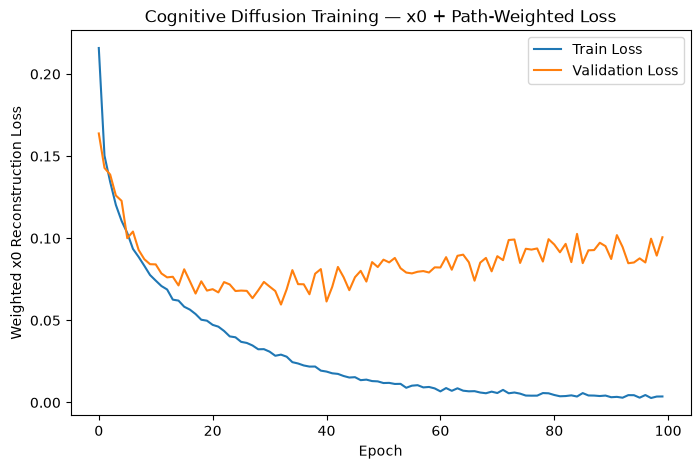

In [95]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Weighted x0 Reconstruction Loss"
)

plt.title(
    "Cognitive Diffusion Training — x0 + Path-Weighted Loss"
)

plt.legend()

plt.show()

## Reverse diffusion / inference

In [143]:
@torch.no_grad()
def p_sample(
    model,
    diffusion,
    x,
    map_latent,
    timestep,
    timestep_index
):

    # ========================================
    # Predict clean x0
    # ========================================

    predicted_x0 = model.predict_x0(
        x,
        map_latent,
        timestep
    )

    # Keep prediction in training data range
    predicted_x0 = torch.clamp(
        predicted_x0,
        -1.0,
        1.0
    )

    # ========================================
    # Extract diffusion coefficients
    # ========================================

    beta_t = extract(
        diffusion.betas,
        timestep,
        x.shape
    )

    alpha_t = extract(
        diffusion.alphas,
        timestep,
        x.shape
    )

    alpha_cumprod_t = extract(
        diffusion.alpha_cumprod,
        timestep,
        x.shape
    )

    alpha_cumprod_prev_t = extract(
        diffusion.alpha_cumprod_prev,
        timestep,
        x.shape
    )

    # ========================================
    # Posterior mean:
    #
    # q(x_{t-1} | x_t, x0)
    # ========================================

    coefficient_x0 = (
        torch.sqrt(
            alpha_cumprod_prev_t
        )
        *
        beta_t
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    coefficient_xt = (
        torch.sqrt(
            alpha_t
        )
        *
        (
            1.0
            -
            alpha_cumprod_prev_t
        )
        /
        (
            1.0
            -
            alpha_cumprod_t
        )
    )

    model_mean = (
        coefficient_x0
        *
        predicted_x0
        +
        coefficient_xt
        *
        x
    )

    # ========================================
    # Final step: no additional noise
    # ========================================

    if timestep_index == 0:
        return model_mean

    # ========================================
    # Posterior variance
    # ========================================

    posterior_variance_t = extract(
        diffusion.posterior_variance,
        timestep,
        x.shape
    )

    noise = torch.randn_like(
        x
    )

    return (
        model_mean
        +
        torch.sqrt(
            posterior_variance_t
        )
        *
        noise
    )

In [144]:
@torch.no_grad()
def sample_path(
    model,
    diffusion,
    grid_map,
    device,
    show_progress=False,
):
    """
    Generate one path sample.

    IMPORTANT:
    During large validation runs, keep show_progress=False.
    This prevents 1000 nested tqdm progress bars from flooding
    Jupyter's output channel.
    """

    model.eval()

    grid_map = grid_map.to(
        device,
        non_blocking=True,
    )

    if grid_map.dim() == 3:
        grid_map = grid_map.unsqueeze(0)

    batch_size = grid_map.shape[0]

    # ========================================
    # Encode map ONCE
    # ========================================

    map_latent = model.encode_map(
        grid_map
    )

    # ========================================
    # Start from pure Gaussian noise
    # ========================================

    x = torch.randn(
        batch_size,
        1,
        IMAGE_SIZE,
        IMAGE_SIZE,
        device=device
    )

    # ========================================
    # Reverse diffusion
    # ========================================

    timestep_iterator = reversed(
        range(
            diffusion.timesteps
        )
    )

    if show_progress:
        timestep_iterator = tqdm(
            timestep_iterator,
            total=diffusion.timesteps,
            desc="Sampling",
            leave=False,
        )

    for i in timestep_iterator:

        timestep = torch.full(
            (batch_size,),
            i,
            device=device,
            dtype=torch.long
        )

        x = p_sample(
            model,
            diffusion,
            x,
            map_latent,
            timestep,
            i
        )

    # ========================================
    # [-1,1] -> [0,1]
    # ========================================

    x = (
        x + 1.0
    ) / 2.0

    x = torch.clamp(
        x,
        0.0,
        1.0
    )

    return x

## Load best model

In [145]:
checkpoint = torch.load(
    os.path.join(
        CHECKPOINT_DIR,
        "best.pt"
    ),
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint[
        "model_state_dict"
    ]
)

model.eval()

print(
    "Loaded epoch:",
    checkpoint["epoch"]
)

print(
    "Validation loss:",
    checkpoint["val_loss"]
)

Loaded epoch: 33
Validation loss: 0.05963403813075274


/tmp/ipykernel_2163/221025179.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


## Predict on validation sample

In [146]:
import matplotlib.pyplot as plt
import numpy as np


@torch.no_grad()
def visualize_samples(
    model,
    diffusion,
    dataset,
    indices,
    device
):
    """
    Visualize multiple validation samples.

    Each row:
        Input Map | A* Ground Truth | Diffusion Prediction
    """

    num_samples = len(indices)

    fig, axes = plt.subplots(
        num_samples,
        3,
        figsize=(15, 5 * num_samples)
    )

    # If only one sample is requested,
    # make axes 2D for consistent indexing
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, idx in enumerate(indices):

        # ========================================
        # Load sample
        # ========================================

        sample = dataset[idx]

        grid_map = sample["map"]
        ground_truth = sample["path"]

        # [-1, 1] -> [0, 1]
        ground_truth_01 = (
            ground_truth + 1.0
        ) / 2.0

        # ========================================
        # Diffusion inference
        # ========================================

        predicted_path = sample_path(
            model,
            diffusion,
            grid_map,
            device
        )

        # ========================================
        # Extract map channels
        # ========================================

        obstacle = grid_map[0].cpu().numpy()
        start_map = grid_map[1].cpu().numpy()
        goal_map = grid_map[2].cpu().numpy()

        gt = ground_truth_01[0].cpu().numpy()

        pred = (
            predicted_path[0, 0]
            .cpu()
            .numpy()
        )

        binary_pred = pred > 0.5

        # ========================================
        # Start / goal coordinates
        # ========================================

        start_y, start_x = np.where(
            start_map > 0.5
        )

        goal_y, goal_x = np.where(
            goal_map > 0.5
        )

        # ========================================
        # Ground-truth coordinates
        # ========================================

        gt_y, gt_x = np.where(
            gt > 0.5
        )

        # ========================================
        # Prediction coordinates
        # ========================================

        pred_y, pred_x = np.where(
            binary_pred
        )

        # ========================================
        # Column 1: Input Map
        # ========================================

        ax = axes[row, 0]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80,
            label="Start"
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120,
            label="Goal"
        )

        ax.set_title(
            f"Sample {idx} — Input Map"
        )

        ax.axis("off")

        if row == 0:
            ax.legend()

        # ========================================
        # Column 2: A* Ground Truth
        # ========================================

        ax = axes[row, 1]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            gt_x,
            gt_y,
            s=8
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120
        )

        ax.set_title(
            f"Sample {idx} — A* Ground Truth"
        )

        ax.axis("off")

        # ========================================
        # Column 3: Diffusion Prediction
        # ========================================

        ax = axes[row, 2]

        ax.imshow(
            obstacle,
            cmap="gray_r"
        )

        ax.scatter(
            pred_x,
            pred_y,
            s=8
        )

        ax.scatter(
            start_x,
            start_y,
            marker="o",
            s=80
        )

        ax.scatter(
            goal_x,
            goal_y,
            marker="*",
            s=120
        )

        ax.set_title(
            f"Sample {idx} — Diffusion Prediction"
        )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

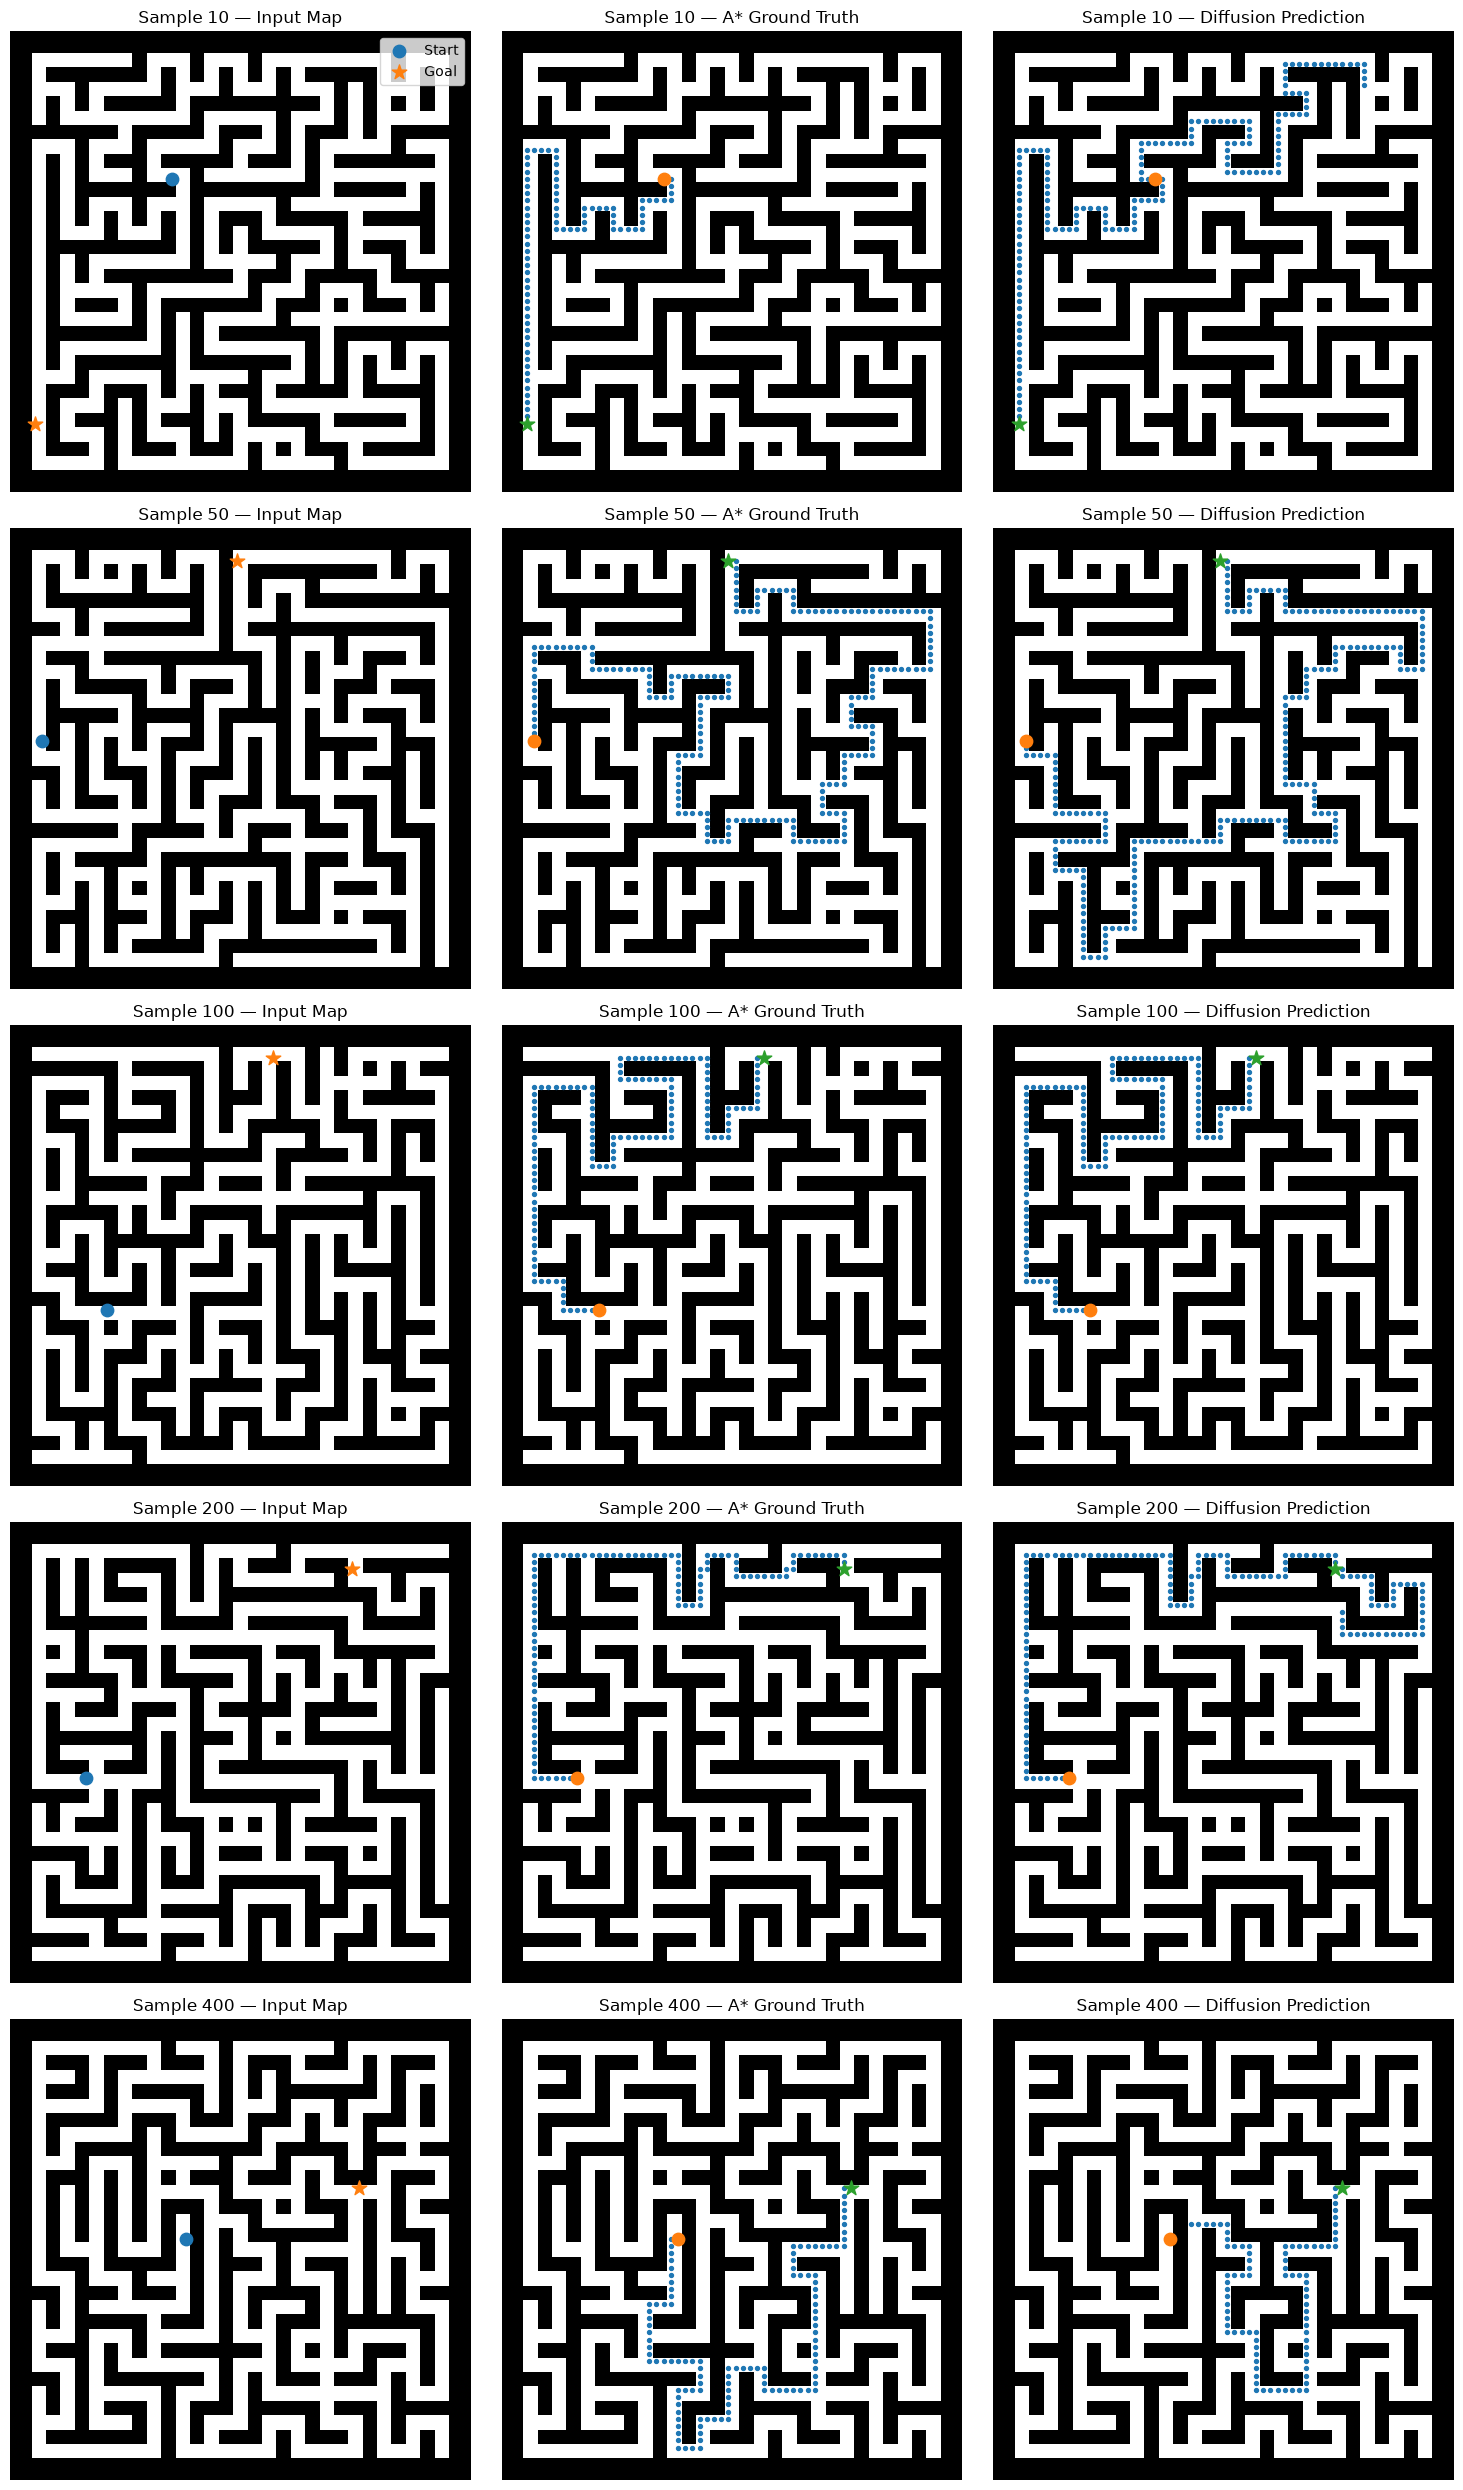

In [147]:
visualize_samples(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    indices=[10, 50, 100, 200, 400],
    device=DEVICE
)

Testing samples: [246, 132, 597, 134, 237, 145, 92, 577, 924, 472]


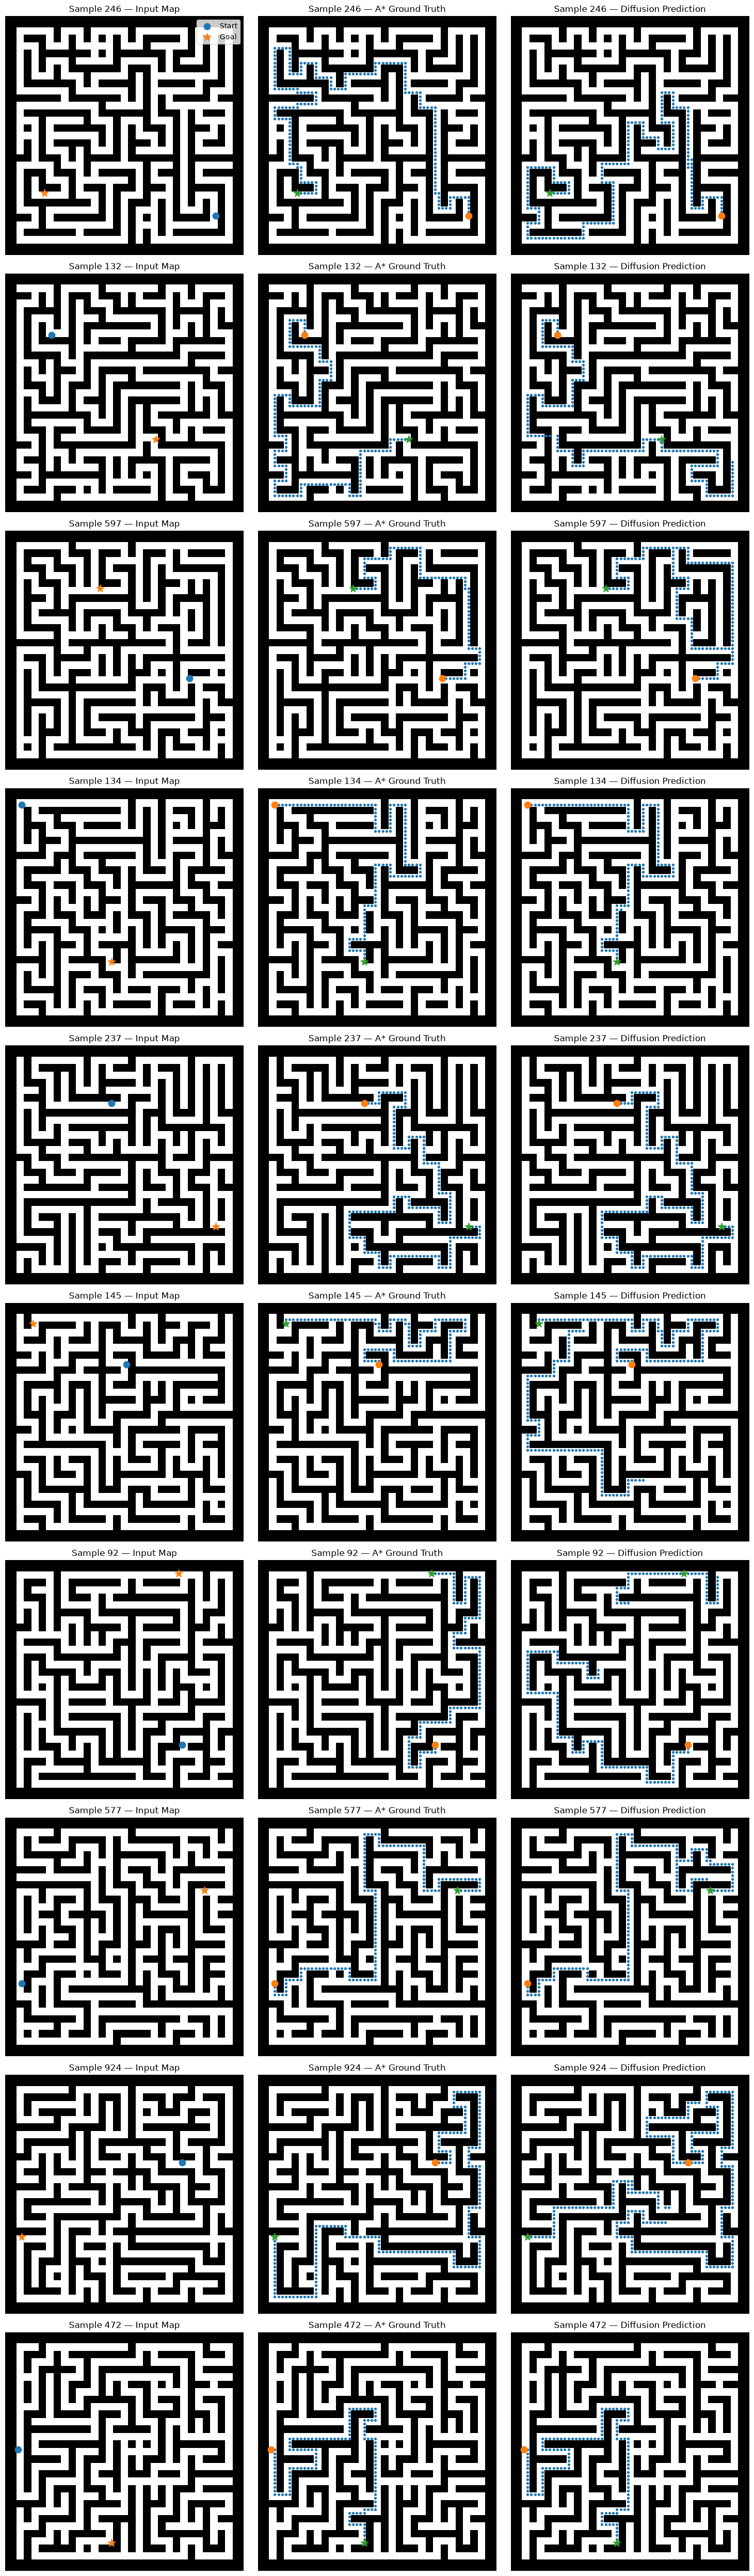

In [148]:
indices = np.random.choice(
    len(val_dataset),
    size=10,
    replace=False
).tolist()

print("Testing samples:", indices)

visualize_samples(
    model=model,
    diffusion=diffusion,
    dataset=val_dataset,
    indices=indices,
    device=DEVICE
)

## Validation evaluator

In [149]:
import os
import json
import random
import numpy as np
import torch
from collections import deque
from tqdm import tqdm

In [150]:
def check_4neighbor_connection(
    binary_path,
    start,
    goal
):
    """
    binary_path: numpy array [H, W], bool
    start: (y, x)
    goal: (y, x)

    Returns:
        True if goal is reachable from start
        using only 4-neighbor path pixels.
    """

    H, W = binary_path.shape

    sy, sx = start
    gy, gx = goal

    # start / goal must both belong to path
    if not binary_path[sy, sx]:
        return False

    if not binary_path[gy, gx]:
        return False

    visited = np.zeros(
        (H, W),
        dtype=bool
    )

    queue = deque()

    queue.append(
        (sy, sx)
    )

    visited[sy, sx] = True

    directions = [
        (-1, 0),   # up
        (1, 0),    # down
        (0, -1),   # left
        (0, 1)     # right
    ]

    while queue:

        y, x = queue.popleft()

        # reached goal
        if (y, x) == (gy, gx):
            return True

        for dy, dx in directions:

            ny = y + dy
            nx = x + dx

            if (
                0 <= ny < H
                and
                0 <= nx < W
            ):

                if (
                    binary_path[ny, nx]
                    and
                    not visited[ny, nx]
                ):

                    visited[ny, nx] = True

                    queue.append(
                        (ny, nx)
                    )

    return False

In [151]:
@torch.no_grad()
def evaluate_single_sample(
    model,
    diffusion,
    sample,
    device,
    threshold=0.5
):
    """
    Evaluate one generated path.
    """

    grid_map = sample["map"]

    # ========================================
    # Generate predicted path
    # Inner diffusion progress is DISABLED.
    # ========================================

    predicted_path = sample_path(
        model,
        diffusion,
        grid_map,
        device,
        show_progress=False,
    )

    pred = (
        predicted_path[0, 0]
        .detach()
        .cpu()
        .numpy()
    )

    binary_path = (
        pred > threshold
    )

    # ========================================
    # Extract raw-map channels
    # ========================================

    obstacle = (
        grid_map[0]
        .cpu()
        .numpy()
        > 0.5
    )

    start_map = (
        grid_map[1]
        .cpu()
        .numpy()
        > 0.5
    )

    goal_map = (
        grid_map[2]
        .cpu()
        .numpy()
        > 0.5
    )

    start_y, start_x = np.where(
        start_map
    )

    goal_y, goal_x = np.where(
        goal_map
    )

    if len(start_y) != 1:
        raise ValueError(
            "Expected exactly one start cell."
        )

    if len(goal_y) != 1:
        raise ValueError(
            "Expected exactly one goal cell."
        )

    start = (
        int(start_y[0]),
        int(start_x[0])
    )

    goal = (
        int(goal_y[0]),
        int(goal_x[0])
    )

    sy, sx = start
    gy, gx = goal

    start_in_path = bool(
        binary_path[sy, sx]
    )

    goal_in_path = bool(
        binary_path[gy, gx]
    )

    collision_mask = (
        binary_path
        &
        obstacle
    )

    collision_count = int(
        collision_mask.sum()
    )

    collision_free = (
        collision_count == 0
    )

    connected = (
        check_4neighbor_connection(
            binary_path,
            start,
            goal
        )
    )

    return {
        "start_in_path": start_in_path,
        "goal_in_path": goal_in_path,
        "collision_free": collision_free,
        "collision_count": collision_count,
        "connected": connected,
    }

In [152]:
def _json_safe_result(result):
    """
    Convert numpy scalar types to ordinary Python types
    so partial results can be safely written as JSON.
    """
    clean = {}

    for key, value in result.items():

        if isinstance(
            value,
            (np.bool_,)
        ):
            clean[key] = bool(value)

        elif isinstance(
            value,
            (np.integer,)
        ):
            clean[key] = int(value)

        elif isinstance(
            value,
            (np.floating,)
        ):
            clean[key] = float(value)

        else:
            clean[key] = value

    return clean


def save_partial_results(
    results,
    save_path,
):
    """
    Atomically save current evaluation results.

    Writes to a temporary file first, then replaces the
    target file. This reduces the chance of a corrupted
    checkpoint if the notebook is interrupted during save.
    """

    tmp_path = (
        save_path + ".tmp"
    )

    with open(
        tmp_path,
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            [
                _json_safe_result(r)
                for r in results
            ],
            f,
            indent=2,
        )

    os.replace(
        tmp_path,
        save_path,
    )


def load_partial_results(
    save_path,
):
    """
    Load previously saved partial results if present.
    """

    if not os.path.exists(
        save_path
    ):
        return []

    with open(
        save_path,
        "r",
        encoding="utf-8",
    ) as f:

        results = json.load(f)

    print(
        f"Resuming from "
        f"{len(results)} completed samples."
    )

    return results


@torch.no_grad()
def evaluate_validation_set_safe(
    model,
    diffusion,
    dataset,
    device,
    num_samples=1000,
    threshold=0.5,
    desc="Evaluating",
    partial_save_path=None,
    save_every=25,
    resume=True,
):
    """
    Robust validation evaluator.

    Features
    --------
    1. ONE outer progress bar only.
    2. No inner diffusion tqdm output.
    3. Autosaves partial results every `save_every` samples.
    4. Can resume after interruption.
    5. Saves again in a finally block before exiting.
    """

    model.eval()

    num_samples = min(
        num_samples,
        len(dataset)
    )

    # --------------------------------------------------------
    # Resume from partial file if requested
    # --------------------------------------------------------

    if (
        resume
        and
        partial_save_path is not None
    ):
        results = load_partial_results(
            partial_save_path
        )
    else:
        results = []

    start_idx = len(
        results
    )

    if start_idx > num_samples:
        raise ValueError(
            "Partial result file contains more samples "
            "than requested."
        )

    if start_idx == num_samples:

        print(
            f"{desc}: already complete "
            f"({num_samples}/{num_samples})."
        )

        return results

    print(
        f"{desc}: evaluating samples "
        f"{start_idx} to {num_samples - 1}"
    )

    # --------------------------------------------------------
    # Only ONE tqdm bar for the whole validation run
    # --------------------------------------------------------

    progress = tqdm(
        range(
            start_idx,
            num_samples
        ),
        desc=desc,
        initial=start_idx,
        total=num_samples,
        dynamic_ncols=True,
        leave=True,
    )

    try:

        for idx in progress:

            sample = dataset[idx]

            result = evaluate_single_sample(
                model=model,
                diffusion=diffusion,
                sample=sample,
                device=device,
                threshold=threshold,
            )

            result["index"] = int(
                idx
            )

            result["sample_index"] = int(
                sample["sample_index"]
            )

            result["sr_source_index"] = int(
                sample["sr_source_index"]
            )

            results.append(
                result
            )

            # ----------------------------------------------
            # Update a compact live success statistic
            # without printing additional lines.
            # ----------------------------------------------

            successes = sum(
                (
                    r["start_in_path"]
                    and
                    r["goal_in_path"]
                    and
                    r["collision_free"]
                    and
                    r["connected"]
                )
                for r in results
            )

            running_success = (
                successes
                /
                len(results)
            )

            progress.set_postfix(
                success=f"{running_success * 100:.1f}%"
            )

            # ----------------------------------------------
            # Periodic autosave
            # ----------------------------------------------

            if (
                partial_save_path is not None
                and
                len(results) % save_every == 0
            ):

                save_partial_results(
                    results,
                    partial_save_path,
                )

        # Final save
        if partial_save_path is not None:

            save_partial_results(
                results,
                partial_save_path,
            )

    except KeyboardInterrupt:

        print(
            "\nEvaluation interrupted by user."
        )

        raise

    finally:

        progress.close()

        if partial_save_path is not None:

            save_partial_results(
                results,
                partial_save_path,
            )

            print(
                f"Partial/final results saved to: "
                f"{partial_save_path}"
            )

    return results

In [153]:
# ============================================================
# EVALUATION 1 — CORRECT SR
# ============================================================

EVAL_RESULTS_DIR = (
    "evaluation_results_test_time_shuffle"
)

os.makedirs(
    EVAL_RESULTS_DIR,
    exist_ok=True,
)

CORRECT_RESULTS_PATH = os.path.join(
    EVAL_RESULTS_DIR,
    "correct_sr_results.json",
)

SHUFFLED_RESULTS_PATH = os.path.join(
    EVAL_RESULTS_DIR,
    "testtime_shuffled_sr_results.json",
)


# ------------------------------------------------------------
# Correct identity mapping
# ------------------------------------------------------------

identity_mapping = make_identity_sr_mapping(
    len(dataset)
)

dataset.set_sr_source_mapping(
    identity_mapping
)

val_idx_array = np.asarray(
    val_dataset.indices,
    dtype=np.int64,
)

assert np.all(
    dataset.sr_source_index[val_idx_array]
    ==
    val_idx_array
)

# ------------------------------------------------------------
# Fixed evaluation randomness
# ------------------------------------------------------------

random.seed(
    EVAL_SEED
)

np.random.seed(
    EVAL_SEED
)

torch.manual_seed(
    EVAL_SEED
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        EVAL_SEED
    )


print(
    "=" * 60
)

print(
    "EVALUATION 1 — CORRECT SR"
)

print(
    "Map A + SR(A)"
)

print(
    "=" * 60
)


results_correct_sr = (
    evaluate_validation_set_safe(
        model=model,
        diffusion=diffusion,
        dataset=val_dataset,
        device=DEVICE,
        num_samples=1000,
        threshold=0.5,
        desc="Correct SR",
        partial_save_path=CORRECT_RESULTS_PATH,
        save_every=25,
        resume=True,
    )
)

EVALUATION 1 — CORRECT SR
Map A + SR(A)
Resuming from 0 completed samples.
Correct SR: evaluating samples 0 to 999


Correct SR: 100%|██████████| 1000/1000 [51:39<00:00,  3.10s/it, success=76.6%]

Partial/final results saved to: evaluation_results_test_time_shuffle/correct_sr_results.json


In [154]:
def summarize_results(
    results
):

    total = len(
        results
    )

    if total == 0:
        print(
            "No results to summarize."
        )
        return

    start_rate = np.mean(
        [
            r["start_in_path"]
            for r in results
        ]
    )

    goal_rate = np.mean(
        [
            r["goal_in_path"]
            for r in results
        ]
    )

    collision_free_rate = np.mean(
        [
            r["collision_free"]
            for r in results
        ]
    )

    connected_rate = np.mean(
        [
            r["connected"]
            for r in results
        ]
    )

    avg_collisions = np.mean(
        [
            r["collision_count"]
            for r in results
        ]
    )

    valid_success = np.mean(
        [
            (
                r["start_in_path"]
                and
                r["goal_in_path"]
                and
                r["collision_free"]
                and
                r["connected"]
            )
            for r in results
        ]
    )

    print(
        f"Samples evaluated: {total}"
    )

    print(
        f"Start included:      "
        f"{start_rate * 100:.2f}%"
    )

    print(
        f"Goal included:       "
        f"{goal_rate * 100:.2f}%"
    )

    print(
        f"Collision-free:      "
        f"{collision_free_rate * 100:.2f}%"
    )

    print(
        f"Connected S -> G:    "
        f"{connected_rate * 100:.2f}%"
    )

    print(
        f"Average collisions:  "
        f"{avg_collisions:.2f}"
    )

    print(
        f"Valid Path Success:  "
        f"{valid_success * 100:.2f}%"
    )

    return float(
        valid_success
    )

In [155]:
print("\nCORRECT-SR RESULTS")
correct_success_rate = summarize_results(results_correct_sr)


CORRECT-SR RESULTS
Samples evaluated: 1000
Start included:      100.00%
Goal included:       100.00%
Collision-free:      97.40%
Connected S -> G:    79.00%
Average collisions:  0.05
Valid Path Success:  76.60%


In [156]:
# ============================================================
# EVALUATION 2 — TEST-TIME SHUFFLED SR
# ============================================================
#
# Same trained model.
# Same validation maps.
# Same evaluation seed.
# Only SR pairing changes:
#
#     Map A + SR(B),  A != B
# ============================================================

testtime_mapping = (
    make_validation_testtime_shuffle_mapping(
        dataset_length=len(dataset),
        val_indices=val_dataset.indices,
        seed=TEST_TIME_SHUFFLE_SEED,
    )
)

dataset.set_sr_source_mapping(
    testtime_mapping
)


# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

val_idx_array = np.asarray(
    val_dataset.indices,
    dtype=np.int64,
)

assert np.all(
    dataset.sr_source_index[val_idx_array]
    !=
    val_idx_array
)

val_set = set(
    val_idx_array.tolist()
)

assert all(
    int(
        dataset.sr_source_index[i]
    )
    in val_set
    for i in val_idx_array
)


print()
print(
    "Example shuffled validation pairings:"
)

for target_idx in val_idx_array[:5]:

    print(
        f"  map/path {int(target_idx):05d}"
        f" <- SR "
        f"{int(dataset.sr_source_index[target_idx]):05d}"
    )


# ------------------------------------------------------------
# Reset exact same RNG seed used for Correct-SR evaluation
# ------------------------------------------------------------

random.seed(
    EVAL_SEED
)

np.random.seed(
    EVAL_SEED
)

torch.manual_seed(
    EVAL_SEED
)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(
        EVAL_SEED
    )


print()
print(
    "=" * 60
)

print(
    "EVALUATION 2 — TEST-TIME SHUFFLED SR"
)

print(
    "Map A + SR(B), A != B"
)

print(
    "MODEL WEIGHTS ARE UNCHANGED"
)

print(
    "=" * 60
)


results_testtime_shuffled = (
    evaluate_validation_set_safe(
        model=model,
        diffusion=diffusion,
        dataset=val_dataset,
        device=DEVICE,
        num_samples=1000,
        threshold=0.5,
        desc="Test-time shuffled SR",
        partial_save_path=SHUFFLED_RESULTS_PATH,
        save_every=25,
        resume=True,
    )
)


Example shuffled validation pairings:
  map/path 00059 <- SR 01051
  map/path 07560 <- SR 02522
  map/path 00624 <- SR 02710
  map/path 01616 <- SR 09933
  map/path 07246 <- SR 06961

EVALUATION 2 — TEST-TIME SHUFFLED SR
Map A + SR(B), A != B
MODEL WEIGHTS ARE UNCHANGED
Test-time shuffled SR: evaluating samples 0 to 999


Test-time shuffled SR: 100%|██████████| 1000/1000 [51:32<00:00,  3.09s/it, success=76.0%]

Partial/final results saved to: evaluation_results_test_time_shuffle/testtime_shuffled_sr_results.json


In [157]:
print(
    "\n================================"
)
print(
    "CORRECT SR — Map A + SR(A)"
)
print(
    "================================"
)

correct_success_rate = summarize_results(
    results_correct_sr
)


print(
    "\n================================"
)
print(
    "TEST-TIME SHUFFLED SR — Map A + SR(B)"
)
print(
    "================================"
)

shuffled_success_rate = summarize_results(
    results_testtime_shuffled
)


delta_pp = (
    correct_success_rate
    -
    shuffled_success_rate
) * 100.0


print(
    "\n================================"
)
print(
    "TEST-TIME SHUFFLE EFFECT"
)
print(
    "================================"
)

print(
    f"Correct SR success:       "
    f"{correct_success_rate * 100:.2f}%"
)

print(
    f"Shuffled SR success:      "
    f"{shuffled_success_rate * 100:.2f}%"
)

print(
    f"Correct - Shuffled:       "
    f"{delta_pp:+.2f} percentage points"
)


CORRECT SR — Map A + SR(A)
Samples evaluated: 1000
Start included:      100.00%
Goal included:       100.00%
Collision-free:      97.40%
Connected S -> G:    79.00%
Average collisions:  0.05
Valid Path Success:  76.60%

TEST-TIME SHUFFLED SR — Map A + SR(B)
Samples evaluated: 1000
Start included:      100.00%
Goal included:       100.00%
Collision-free:      97.60%
Connected S -> G:    78.10%
Average collisions:  0.05
Valid Path Success:  76.00%

TEST-TIME SHUFFLE EFFECT
Correct SR success:       76.60%
Shuffled SR success:      76.00%
Correct - Shuffled:       +0.60 percentage points


In [158]:
# ============================================================
# Paired per-map reliance analysis
# ============================================================

def is_valid_success(
    result
):
    return (
        result["start_in_path"]
        and
        result["goal_in_path"]
        and
        result["collision_free"]
        and
        result["connected"]
    )


if (
    len(results_correct_sr)
    !=
    len(results_testtime_shuffled)
):
    raise ValueError(
        "Correct and shuffled evaluations "
        "must contain the same number of samples."
    )


correct_success = np.asarray(
    [
        is_valid_success(r)
        for r in results_correct_sr
    ],
    dtype=bool,
)

shuffled_success = np.asarray(
    [
        is_valid_success(r)
        for r in results_testtime_shuffled
    ],
    dtype=bool,
)


both_success = int(
    np.sum(
        correct_success
        &
        shuffled_success
    )
)

both_fail = int(
    np.sum(
        (~correct_success)
        &
        (~shuffled_success)
    )
)

correct_only = int(
    np.sum(
        correct_success
        &
        (~shuffled_success)
    )
)

shuffled_only = int(
    np.sum(
        (~correct_success)
        &
        shuffled_success
    )
)


print()
print(
    "Paired map-level outcomes"
)
print(
    "-------------------------"
)

print(
    "Both succeed:              ",
    both_success
)

print(
    "Both fail:                 ",
    both_fail
)

print(
    "Correct SR only succeeds:  ",
    correct_only
)

print(
    "Shuffled SR only succeeds: ",
    shuffled_only
)


# Restore normal mapping at the end.
dataset.set_sr_source_mapping(
    identity_mapping
)

print()
print(
    "Dataset SR mapping restored "
    "to correct identity mapping."
)


Paired map-level outcomes
-------------------------
Both succeed:               745
Both fail:                  219
Correct SR only succeeds:   21
Shuffled SR only succeeds:  15

Dataset SR mapping restored to correct identity mapping.
